In [ ]:
# installing dependencies
!pip install rdkit Pymatgen shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 32.0 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549 sha256=2406435f514b4b6724b6d4357e603fe5060879fa91cddfa0ce0e30e9e1d645f0
  Stored in directory: /root/.cache/pip/wheels/1f/7d/e9/1ff2509f13767a55df1279744ad

In [ ]:
# Dependencies & Configuration

import os
import json
import re
import warnings
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import joblib
import shap

from pathlib import Path
from typing import Dict, List, Optional
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.impute import KNNImputer
import shap
from pymatgen.core import Composition

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# PLOTTING STANDARDS

def setup_plotting_style():
    """Sets consistent figure aesthetics for publication."""
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.4)
    plt.rcParams.update({
        'figure.figsize': (6, 4),
        'figure.dpi': 100,
        'savefig.dpi': 300,
        'savefig.format': 'pdf',
        'font.family': 'sans-serif',
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'legend.fontsize': 10,
        'lines.linewidth': 2,
    })

def save_and_show(fig, filename: str, output_dir: Path):
    """Saves figure as PDF and displays it."""
    path = output_dir / f"{filename}.pdf"
    fig.savefig(path, bbox_inches='tight')
    print(f"Figure saved: {path}")
    plt.show()
    plt.close(fig)

setup_plotting_style()

# CONFIGURATION
class Config:
    """Simulation parameters and physical constants."""

    # Data Sources
    QMOF_ARTICLE_ID = 13147324
    COREMOF_ZENODO_URL = "https://zenodo.org/record/3677685/files/2019-11-01-ASR-public_12020.csv?download=1"

    # Directories
    DATA_DIR = Path("MOF_Dataset")
    QMOF_DIR = DATA_DIR / "QMOF"
    COREMOF_DIR = DATA_DIR / "CoRE_MOF"
    OUTPUT_DIR = DATA_DIR / "Processed"

    # g-C3N4 Reference Potentials (V vs NHE)
    GCN_BAND_GAP = 2.7
    GCN_CB_POSITION = -1.1
    GCN_VB_POSITION = 1.6

    # Correction Factors
    PBE_SCISSOR_CORRECTION = 0.7  # eV (Empirical correction for DFT band gaps)

    # Screening Thresholds
    MAX_BANDGAP_VISIBLE = 3.4     # eV (Includes near-UV/Visible edge)
    MIN_BANDGAP_STABLE = 1.5      # eV (Excludes narrow-gap semiconductors)
    MIN_PLD_ACCESSIBILITY = 3.5   # Å (Minimum pore size for reagent diffusion)

    # Heterojunction Alignment Thresholds
    TYPE_II_CB_MAX = -0.9         # eV (Ensures driving force for electron transfer)

    # Sanderson Electronegativity (J. Chem. Educ. 1988, 65, 112)
    SANDERSON_ELECTRONEGATIVITY = {
        'H': 2.59, 'Li': 0.89, 'Be': 1.81, 'B': 2.28, 'C': 3.79, 'N': 4.49, 'O': 5.21, 'F': 6.54,
        'Na': 0.85, 'Mg': 1.32, 'Al': 1.71, 'Si': 2.14, 'P': 2.52, 'S': 2.96, 'Cl': 4.28,
        'K': 0.74, 'Ca': 0.95, 'Sc': 1.20, 'Ti': 1.38, 'V': 1.53, 'Cr': 1.65, 'Mn': 1.60,
        'Fe': 1.64, 'Co': 1.70, 'Ni': 1.75, 'Cu': 1.98, 'Zn': 1.66, 'Ga': 1.82, 'Ge': 2.31,
        'As': 2.26, 'Se': 3.01, 'Br': 4.22, 'Rb': 0.71, 'Sr': 0.90, 'Y': 1.11, 'Zr': 1.32,
        'Nb': 1.41, 'Mo': 1.47, 'Tc': 1.51, 'Ru': 1.54, 'Rh': 1.56, 'Pd': 1.58, 'Ag': 1.87,
        'Cd': 1.52, 'In': 1.66, 'Sn': 1.82, 'Sb': 1.98, 'Te': 2.34, 'I': 3.70,
        'Cs': 0.66, 'Ba': 0.88, 'La': 1.09, 'Ce': 1.01, 'Pr': 1.01, 'Nd': 1.01,
        'Sm': 1.01, 'Eu': 1.01, 'Gd': 1.01, 'Tb': 1.01, 'Dy': 1.01, 'Ho': 1.01,
        'Er': 1.01, 'Tm': 1.01, 'Yb': 1.01, 'Lu': 1.11, 'Hf': 1.16, 'Ta': 1.34,
        'W': 1.47, 'Re': 1.46, 'Os': 1.52, 'Ir': 1.55, 'Pt': 1.44, 'Au': 1.42,
        'Hg': 1.44, 'Tl': 1.44, 'Pb': 1.55, 'Bi': 1.67, 'Th': 1.11, 'U': 1.22
    }

    # Ionic Radii (Å)
    IONIC_RADII = {
        'Li': 76, 'Be': 45, 'Na': 102, 'Mg': 72, 'Al': 54, 'Si': 40,
        'K': 138, 'Ca': 100, 'Sc': 75, 'Ti': 61, 'V': 64, 'Cr': 62,
        'Mn': 83, 'Fe': 65, 'Co': 75, 'Ni': 69, 'Cu': 73, 'Zn': 74,
        'Ga': 62, 'Ge': 53, 'Rb': 152, 'Sr': 118, 'Y': 90, 'Zr': 72,
        'Nb': 64, 'Mo': 65, 'Tc': 60, 'Ru': 62, 'Rh': 67, 'Pd': 86,
        'Ag': 115, 'Cd': 95, 'In': 80, 'Sn': 69, 'Sb': 76, 'Cs': 167,
        'Ba': 135, 'La': 103, 'Ce': 101, 'Pr': 99, 'Nd': 98, 'Sm': 96,
        'Eu': 95, 'Gd': 94, 'Tb': 92, 'Dy': 91, 'Ho': 90, 'Er': 89,
        'Tm': 88, 'Yb': 87, 'Lu': 86, 'Hf': 71, 'Ta': 64, 'W': 60,
        'Re': 63, 'Os': 63, 'Ir': 63, 'Pt': 63, 'Au': 85, 'Hg': 102,
        'Tl': 89, 'Pb': 119, 'Bi': 103, 'Th': 94, 'U': 89
    }

    # Empirical Water Stability Score (1-5 Scale)
    WATER_STABILITY = {
        'Zr': 5, 'Hf': 5, 'Ti': 4, 'Fe': 4, 'Cr': 4, 'Al': 4,
        'Cu': 3, 'Co': 3, 'Ni': 3, 'Zn': 3, 'Mg': 3,
        'Cd': 2, 'Mn': 2, 'Ca': 2, 'Ag': 2,
        'Pb': 1, 'Hg': 1
    }

Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Setup complete. Output directory: {Config.OUTPUT_DIR}")

Setup complete. Output directory: MOF_Dataset/Processed


In [ ]:
# Data Loading & Processing Classes

class DataDownloader:
    """Manages retrieval of QMOF and CoRE-MOF datasets."""

    @staticmethod
    def download_qmof(force_redownload: bool = False) -> Path:
        Config.QMOF_DIR.mkdir(parents=True, exist_ok=True)
        json_path = Config.QMOF_DIR / "qmof.json"

        if json_path.exists() and not force_redownload:
            return Config.QMOF_DIR

        print("Downloading QMOF database...")
        api_url = f"https://api.figshare.com/v2/articles/{Config.QMOF_ARTICLE_ID}/files"
        try:
            files = requests.get(api_url, timeout=30).json()
            target = next((f for f in files if "qmof_database" in f['name'] and f['name'].endswith('.zip')), None)

            if not target: raise ValueError("QMOF zip file not found")

            response = requests.get(target['download_url'], stream=True, timeout=300)
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                z.extractall(Config.QMOF_DIR)
            return Config.QMOF_DIR
        except Exception as e:
            raise RuntimeError(f"QMOF download failed: {e}")

    @staticmethod
    def download_coremof(force_redownload: bool = False) -> pd.DataFrame:
        Config.COREMOF_DIR.mkdir(parents=True, exist_ok=True)
        cache_path = Config.COREMOF_DIR / "coremof_2019.csv"

        if cache_path.exists() and not force_redownload:
            return pd.read_csv(cache_path)

        print("Downloading CoRE-MOF 2019...")
        try:
            response = requests.get(Config.COREMOF_ZENODO_URL, timeout=60)
            df = pd.read_csv(io.StringIO(response.content.decode('utf-8', errors='ignore')))

            # ID extraction
            if 'filename' in df.columns:
                df['Refcode_Clean'] = df['filename'].astype(str).str.split('_').str[0].str.split('.').str[0]
            elif 'CSD_code' in df.columns:
                 df['Refcode_Clean'] = df['CSD_code']
            else:
                df['Refcode_Clean'] = df.index.astype(str)

            df.to_csv(cache_path, index=False)
            return df
        except Exception as e:
            raise RuntimeError(f"CoRE-MOF download failed: {e}")

class QMOFLoader:
    """Parses and normalizes QMOF JSON data."""

    @staticmethod
    def load() -> pd.DataFrame:
        print("\nLoading QMOF data...")
        json_files = list(Config.QMOF_DIR.rglob("*.json"))
        json_files = [f for f in json_files if "structure" not in f.name]

        if not json_files:
            raise FileNotFoundError(f"No QMOF JSON found in {Config.QMOF_DIR}")

        json_path = max(json_files, key=lambda x: x.stat().st_size)
        print(f"Loading {json_path.name}...")

        with open(json_path, 'r') as f:
            data = json.load(f)

        df = pd.json_normalize(data)

        # Ensure column mapping does not produce duplicates
        col_map = QMOFLoader._find_columns(df.columns)
        df = df.rename(columns=col_map)

        # Filter for duplicates immediately
        df = df.loc[:, ~df.columns.duplicated()].copy()

        required_cols = ['qmof_id', 'refcode', 'formula', 'EgPBE', 'pld', 'lcd', 'void_fraction']
        smiles_col = next((c for c in df.columns if 'smiles' in c.lower()), None)

        if smiles_col:
            required_cols.append(smiles_col)
            df = df.rename(columns={smiles_col: 'Linker_SMILES'})

        # Use intersection to avoid KeyErrors if a column is missing
        present_cols = [c for c in required_cols if c in df.columns]
        df = df[present_cols].copy()

        # Safe Refcode generation
        if 'refcode' in df.columns:
            df['Refcode_Clean'] = df['refcode'].astype(str).str.split('_').str[0].str.upper()
        elif 'qmof_id' in df.columns:
             # Fallback if refcode is missing
             df['Refcode_Clean'] = df['qmof_id']
        else:
             df['Refcode_Clean'] = df.index.astype(str)

        print(f"✓ Loaded {len(df)} QMOF entries")
        return df

    @staticmethod
    def _find_columns(columns: List[str]) -> Dict[str, str]:
        mapping = {}
        found_targets = set() # Track targets to prevent duplicate columns

        # Priority 1: PBE Bandgap
        for col in columns:
            if 'pbe' in col.lower() and ('gap' in col.lower() or 'eg' in col.lower()):
                mapping[col] = 'EgPBE'
                break

        patterns = {
            'qmof_id': ['qmof_id', 'id'],
            'refcode': ['refcode', 'csd_code'],
            'formula': ['formula', 'composition'],
            'pld': ['pld', 'pore_limiting_diameter'],
            'lcd': ['lcd', 'largest_cavity_diameter'],
            'void_fraction': ['void_fraction', 'porosity']
        }

        for target, candidates in patterns.items():
            for col in columns:
                # Only map if we haven't found this target yet (Prevents duplicates)
                if target not in found_targets:
                    if any(cand == col.lower() for cand in candidates) or any(cand in col.lower() for cand in candidates):
                        mapping[col] = target
                        found_targets.add(target)
                        break
        return mapping

class FeatureExtractor:
    """Extracts chemical and structural features."""

    @staticmethod
    def extract_metal(formula: str) -> str:
        # handling for non-string inputs
        if pd.isna(formula) or not isinstance(formula, (str, bytes)):
            return "Unknown"

        formula = str(formula)
        metals = ['Zr', 'Ti', 'Hf', 'Cr', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Cd',
                  'Mn', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Al', 'Ga', 'In', 'Y',
                  'La', 'Ce', 'Pr', 'Nd', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au']
        for metal in metals:
            if re.search(rf'\b{metal}\d*', formula): return metal
        match = re.search(r'([A-Z][a-z]?)', formula)
        return match.group(1) if match else "Unknown"

    @staticmethod
    def get_metal_features(metal: str) -> Dict[str, float]:
        return {
            'Metal_Electronegativity': Config.SANDERSON_ELECTRONEGATIVITY.get(metal, np.nan),
            'Metal_Ionic_Radius': Config.IONIC_RADII.get(metal, np.nan),
            'Aqueous_Stability_Score': Config.WATER_STABILITY.get(metal, 2.5)
        }

    @staticmethod
    def extract_linker_formula(formula: str, metal: str) -> str:
        if pd.isna(formula) or metal == "Unknown": return ""
        return re.sub(rf'{metal}\d*', '', str(formula)).strip()

    @staticmethod
    def calculate_linker_features(linker_formula: str) -> Dict[str, float]:
        if not linker_formula:
            return {'C_count': 0, 'N_count': 0, 'O_count': 0, 'Aromatic_Ratio': 0,
                    'Linker_Electronegativity': np.nan, 'Pi_Conjugation_Proxy': 0}

        counts = {el: FeatureExtractor._count_element(linker_formula, el) for el in ['C', 'N', 'O', 'H']}
        total = sum([counts['C'], counts['N'], counts['O'], 1])
        # Avoid division by zero
        aromatic_ratio = counts['C'] / (counts['H'] + 1) if counts['H'] > 0 else 0

        chi_C, chi_N, chi_O = 3.79, 4.49, 5.21
        linker_chi = (chi_C * counts['C'] + chi_N * counts['N'] + chi_O * counts['O']) / total
        pi_proxy = max(0, counts['C'] - counts['H']/2) / (counts['C'] + 1)

        return {
            'C_count': counts['C'], 'N_count': counts['N'], 'O_count': counts['O'],
            'Aromatic_Ratio': aromatic_ratio, 'Linker_Electronegativity': linker_chi,
            'Pi_Conjugation_Proxy': pi_proxy
        }

    @staticmethod
    def _count_element(formula: str, element: str) -> int:
        match = re.search(rf'{element}(\d+)', str(formula))
        return int(match.group(1)) if match else (1 if element in str(formula) else 0)

    @staticmethod
    def calculate_homo_lumo(linker_feats: Dict, band_gap: float) -> Dict[str, float]:
        pi_factor = linker_feats.get('Pi_Conjugation_Proxy', 0)
        linker_gap = 3.0 + (1 - pi_factor) * 2.0
        chi = linker_feats.get('Linker_Electronegativity', 2.8)
        lumo = -chi - 1.5
        homo = lumo + linker_gap
        return {'Linker_HOMO_approx': homo, 'Linker_LUMO_approx': lumo}

class BandAlignmentCalculator:
    """Calculates band positions using Butler's atomic electronegativity scale."""

    @staticmethod
    def estimate_cb_position(metal: str, band_gap: float, linker_chi: float) -> float:
        if pd.isna(band_gap) or metal == "Unknown": return np.nan
        chi_metal = Config.SANDERSON_ELECTRONEGATIVITY.get(metal, 1.5)
        chi_linker = linker_chi if not pd.isna(linker_chi) else 3.5

        # Weighted electronegativity (0.75 linker dominance)
        chi_mof = 0.75 * chi_linker + 0.25 * chi_metal
        # Butler's equation: E_CB = χ - E_e - 0.5 * Eg
        return chi_mof - 4.5 - 0.5 * band_gap

    @staticmethod
    def assess_compatibility(cb_mof: float, vb_mof: float, eg_mof: float, pld: float) -> Dict:
        """Evaluates Type-II potential ONLY (Z-Scheme removed)."""
        visible_active = (eg_mof >= Config.MIN_BANDGAP_STABLE) and (eg_mof <= Config.MAX_BANDGAP_VISIBLE)
        pore_accessible = pld > Config.MIN_PLD_ACCESSIBILITY if not pd.isna(pld) else False

        # check for Type-II (CB < -0.9 eV)
        type_ii = (cb_mof < Config.TYPE_II_CB_MAX) and visible_active

        # Compatibility is now only based on Type-II and pore accessibility
        is_compatible = type_ii and pore_accessible

        # Simplified Mechanism Logic
        if type_ii: mechanism = "Type-II"
        else: mechanism = "None"

        return {
            'Is_Compatible': int(is_compatible),
            'Mechanism': mechanism,
            'Is_Type_II': int(type_ii)
        }

In [ ]:
# Data Pipeline Execution

print("Executing MOF Photocatalyst Screening Dataset Creation Pipeline...")

# 1. Download & Load
DataDownloader.download_qmof()
coremof_df = DataDownloader.download_coremof()

# Load QMOF
qmof_df = QMOFLoader.load()

# Prepare CoRE-MOF
desired_core_cols = ['Refcode_Clean', 'LCD', 'PLD', 'void_fraction']
available_core_cols = [c for c in desired_core_cols if c in coremof_df.columns]
core_subset = coremof_df[available_core_cols].copy()

# 2. Merge
if 'Refcode_Clean' not in qmof_df.columns:
    qmof_df['Refcode_Clean'] = qmof_df.index.astype(str)

final_df = qmof_df.merge(core_subset, on='Refcode_Clean', how='left', suffixes=('_qmof', '_core'))

# Merge duplicate PLD columns if they exist
if 'PLD_core' in final_df.columns and 'PLD_qmof' in final_df.columns:
    final_df['PLD'] = final_df['PLD_core'].fillna(final_df['PLD_qmof'])
elif 'PLD' in final_df.columns and 'pld' in final_df.columns:
    final_df['PLD'] = final_df['PLD'].fillna(final_df['pld'])

# 3. Feature Engineering
print(" - Calculating Material Properties...")

# Explicit string conversion to avoid Series ambiguity
final_df['formula'] = final_df['formula'].astype(str)

final_df['Metal_Node'] = final_df['formula'].apply(FeatureExtractor.extract_metal)
metal_feats = final_df['Metal_Node'].apply(FeatureExtractor.get_metal_features)
final_df = pd.concat([final_df, pd.DataFrame(metal_feats.tolist())], axis=1)

final_df['Linker_Formula'] = final_df.apply(lambda x: FeatureExtractor.extract_linker_formula(x['formula'], x['Metal_Node']), axis=1)
linker_feats = final_df['Linker_Formula'].apply(FeatureExtractor.calculate_linker_features)
final_df = pd.concat([final_df, pd.DataFrame(linker_feats.tolist())], axis=1)

hl_approx = final_df.apply(lambda x: FeatureExtractor.calculate_homo_lumo(
    {'Pi_Conjugation_Proxy': x['Pi_Conjugation_Proxy'], 'Linker_Electronegativity': x['Linker_Electronegativity']},
    x.get('EgPBE')), axis=1)
final_df = pd.concat([final_df, pd.DataFrame(hl_approx.tolist())], axis=1)

# 4. Band Alignment
print(" - Determining Compatibility...")
final_df['Eg_Corrected'] = final_df['EgPBE'] + Config.PBE_SCISSOR_CORRECTION
final_df['Estimated_CB_Position'] = final_df.apply(lambda x: BandAlignmentCalculator.estimate_cb_position(
    x['Metal_Node'], x['Eg_Corrected'], x['Linker_Electronegativity']), axis=1)
final_df['Estimated_VB_Position'] = final_df['Estimated_CB_Position'] + final_df['Eg_Corrected']

comp = final_df.apply(lambda x: BandAlignmentCalculator.assess_compatibility(
    x['Estimated_CB_Position'], x['Estimated_VB_Position'], x['Eg_Corrected'], x.get('PLD', np.nan)), axis=1)
final_df = pd.concat([final_df, pd.DataFrame(comp.tolist())], axis=1)

# 5. Clean
final_df.dropna(subset=['EgPBE'], inplace=True)
final_df = final_df[(final_df['EgPBE'] > 0.1) & (final_df['EgPBE'] < 10)]
final_df.to_csv(Config.OUTPUT_DIR / "mof_dataset_processed.csv", index=False)
print(f"Pipeline Complete. Processed {len(final_df)} MOFs.")

Executing MOF Photocatalyst Screening Dataset Creation Pipeline...

Loading QMOF data...
Loading qmof.json...
✓ Loaded 20372 QMOF entries
 - Calculating Material Properties...
 - Determining Compatibility...
Pipeline Complete. Processed 20152 MOFs.


In [ ]:
df = final_df.copy()

# DATA INSPECTION

print("\n" + "="*40)
print("DATASET INSPECTION")
print("="*40)

print("\n1. First 5 Rows:")
display(df.head())

print("\n2. Statistical Summary:")
display(df.describe())

print("\n3. Dataset Info:")
df.info()

print("\n4. Compatibility Counts:")
print(df['Is_Compatible'].value_counts())
print("="*40 + "\n")


DATASET INSPECTION

1. First 5 Rows:


,qmof_id,formula,EgPBE,pld,lcd,Refcode_Clean,LCD,PLD,Metal_Node,Metal_Electronegativity,...,Linker_Electronegativity,Pi_Conjugation_Proxy,Linker_HOMO_approx,Linker_LUMO_approx,Eg_Corrected,Estimated_CB_Position,Estimated_VB_Position,Is_Compatible,Mechanism,Is_Type_II
0,qmof-8a95c27,Ba2CuC6H14O16,0.632527,0.68822,1.35480,qmof-8a95c27,NaN,0.68822,Ba,0.88,...,4.613043,0.000000,-1.113043,-6.113043,1.332527,-1.486481,-0.153954,0,None,0
1,qmof-019ba28,Cu12C36H56I16N4S4,1.134232,1.18570,2.13507,qmof-019ba28,NaN,1.18570,Cu,1.98,...,3.765854,0.216216,-0.698286,-5.265854,1.834232,-2.097726,-0.263494,0,Type-II,1
2,qmof-830ed1c,Co4C48H32N8O16,0.345448,2.36128,4.21176,qmof-830ed1c,NaN,2.36128,Co,1.70,...,4.126027,0.653061,-1.932150,-5.626027,1.045448,-1.503203,-0.457755,0,None,0
3,qmof-5bd4a24,Co4C48H32N8O16,0.342645,2.14542,3.27957,qmof-5bd4a24,NaN,2.14542,Co,1.70,...,4.126027,0.653061,-1.932150,-5.626027,1.042645,-1.501802,-0.459157,0,None,0
4,qmof-644aab4,Zn2C50H32N6O8S4,1.973007,1.33452,2.03948,qmof-644aab4,NaN,1.33452,Zn,1.66,...,3.971077,0.666667,-1.804410,-5.471077,2.673007,-2.443196,0.229811,0,Type-II,1



2. Statistical Summary:


,EgPBE,pld,lcd,LCD,PLD,Metal_Electronegativity,Metal_Ionic_Radius,Aqueous_Stability_Score,C_count,N_count,...,Aromatic_Ratio,Linker_Electronegativity,Pi_Conjugation_Proxy,Linker_HOMO_approx,Linker_LUMO_approx,Eg_Corrected,Estimated_CB_Position,Estimated_VB_Position,Is_Compatible,Is_Type_II
count,20152.000000,20152.000000,20152.000000,0.0,20152.000000,20148.000000,20129.000000,20152.000000,20152.000000,20152.000000,...,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000,20152.000000
mean,2.109844,2.961871,4.464509,NaN,2.961871,1.574340,83.931393,2.708639,45.064113,8.563517,...,1.275001,4.137517,0.525212,-1.687942,-5.637517,2.809844,-2.408203,0.401642,0.173779,0.537763
std,1.117309,3.535178,4.123104,NaN,3.535178,0.328862,18.558883,0.674641,32.677637,9.762290,...,0.774887,0.200268,0.200264,0.404269,0.200268,1.117309,0.584187,0.569708,0.378929,0.498584
min,0.100632,0.000000,0.783710,NaN,0.000000,0.660000,45.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-3.052517,-6.542462,0.800632,-5.127592,-1.977408,0.000000,0.000000
25%,1.130452,1.005283,2.002302,NaN,1.005283,1.520000,73.000000,2.000000,24.000000,2.000000,...,0.888889,4.010870,0.444444,-1.941598,-5.755119,1.830452,-2.827913,-0.057339,0.000000,0.000000
50%,2.161098,1.325945,2.713130,NaN,1.325945,1.660000,74.000000,3.000000,36.000000,6.000000,...,1.169521,4.114925,0.571429,-1.736373,-5.614925,2.861098,-2.451395,0.391847,0.000000,1.000000
75%,2.894901,3.498755,5.068950,NaN,3.498755,1.710000,95.000000,3.000000,56.000000,12.000000,...,1.466667,4.255119,0.656716,-1.483354,-5.510870,3.594901,-1.928356,0.775518,0.000000,1.000000
max,6.445777,44.416710,44.893720,NaN,44.416710,4.220000,167.000000,5.000000,264.000000,160.000000,...,19.200000,5.042462,0.989691,3.500000,-1.500000,7.145777,-0.893392,2.637419,1.000000,1.000000



3. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 20152 entries, 0 to 20371
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   qmof_id                   20152 non-null  object 
 1   formula                   20152 non-null  object 
 2   EgPBE                     20152 non-null  float64
 3   pld                       20152 non-null  float64
 4   lcd                       20152 non-null  float64
 5   Refcode_Clean             20152 non-null  object 
 6   LCD                       0 non-null      float64
 7   PLD                       20152 non-null  float64
 8   Metal_Node                20152 non-null  object 
 9   Metal_Electronegativity   20148 non-null  float64
 10  Metal_Ionic_Radius        20129 non-null  float64
 11  Aqueous_Stability_Score   20152 non-null  float64
 12  Linker_Formula            20152 non-null  object 
 13  C_count                   20152 non-null  int64 

SENSITIVITY ANALYSIS: BAND GAP CORRECTION
Figure saved: MOF_Dataset/Processed/sensitivity_analysis_clean.pdf


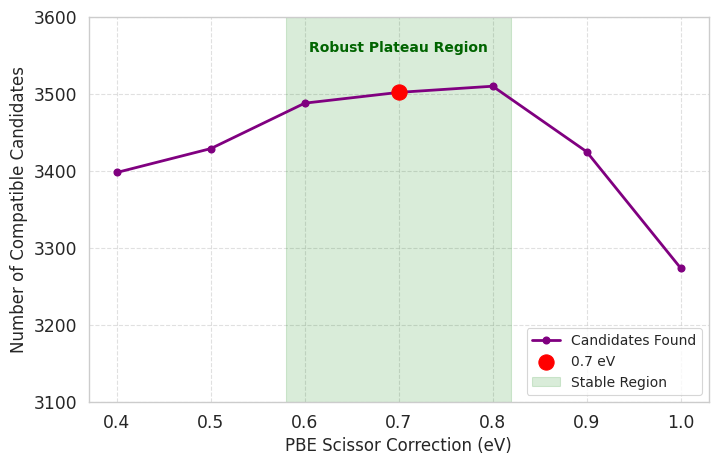

Sensitivity Analysis Complete. Stable plateau identified around 0.7 eV.


In [ ]:
# SENSITIVITY ANALYSIS: BAND GAP CORRECTION

print("SENSITIVITY ANALYSIS: BAND GAP CORRECTION")

def perform_sensitivity_analysis(data_df):
    """
    Tests robustness of the 0.7 eV Scissor Correction.
    """
    correction_range = np.arange(0.4, 1.1, 0.1)
    compatibility_counts = []

    # using a temp copy to avoid messing up main data
    temp_df = data_df.copy()

    for correction in correction_range:
        # Apply new correction
        temp_eg = temp_df['EgPBE'] + correction

        # Recalculate Alignment (Simplified for speed)
        chi_mof = 0.75 * temp_df['Linker_Electronegativity'] + 0.25 * temp_df['Metal_Electronegativity']
        est_cb = chi_mof - 4.5 - 0.5 * temp_eg

        # Check Thresholds
        is_type_ii = (est_cb < Config.TYPE_II_CB_MAX)
        is_visible = (temp_eg >= Config.MIN_BANDGAP_STABLE) & (temp_eg <= Config.MAX_BANDGAP_VISIBLE)
        is_accessible = temp_df['PLD'] > Config.MIN_PLD_ACCESSIBILITY

        # Count compatible
        num_compatible = (is_type_ii & is_visible & is_accessible).sum()
        compatibility_counts.append(num_compatible)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(correction_range, compatibility_counts, marker='o', linestyle='-', color='purple', linewidth=2, label='Candidates Found')

    current_val = Config.PBE_SCISSOR_CORRECTION
    idx = (np.abs(correction_range - current_val)).argmin()
    current_count = compatibility_counts[idx]

    ax.scatter([current_val], [current_count], color='red', s=120, zorder=5, label=f'{current_val} eV')

    ax.axvspan(0.58, 0.82, color='green', alpha=0.15, label='Stable Region')

    ax.text(0.7, 3550, "Robust Plateau Region",
            ha='center', va='bottom', color='darkgreen', fontweight='bold', fontsize=10)

    ax.set_ylim(3100, 3600)
    ax.legend(loc='lower right', frameon=True)
    ax.set_xlabel('PBE Scissor Correction (eV)', fontsize=12)
    ax.set_ylabel('Number of Compatible Candidates', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    save_and_show(fig, "sensitivity_analysis_clean", Config.OUTPUT_DIR)
    print(f"Sensitivity Analysis Complete. Stable plateau identified around {current_val} eV.")

# Execute
perform_sensitivity_analysis(df)

Figure saved: MOF_Dataset/Processed/volcano_plot_filtered.pdf


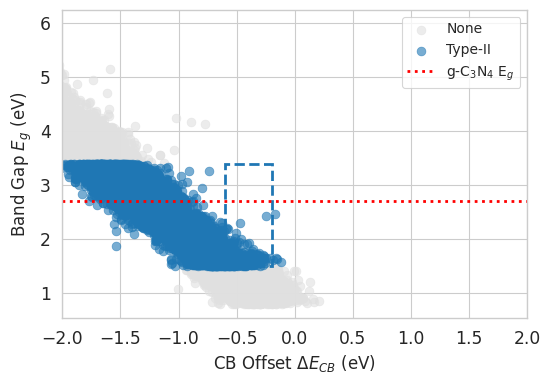

Figure saved: MOF_Dataset/Processed/compatibility_distribution.pdf


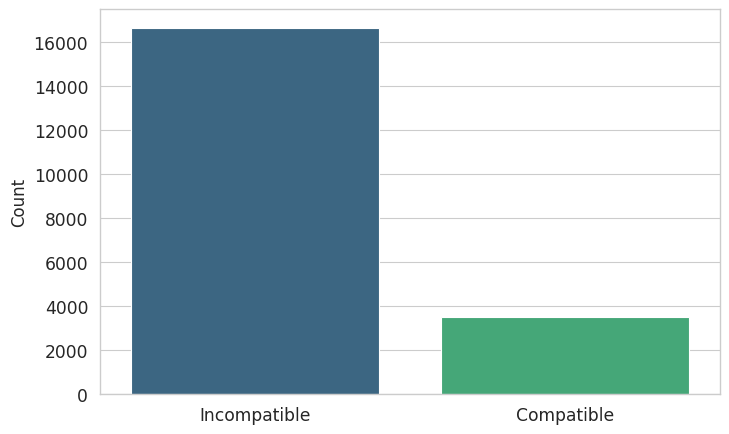

Figure saved: MOF_Dataset/Processed/metal_distribution.pdf


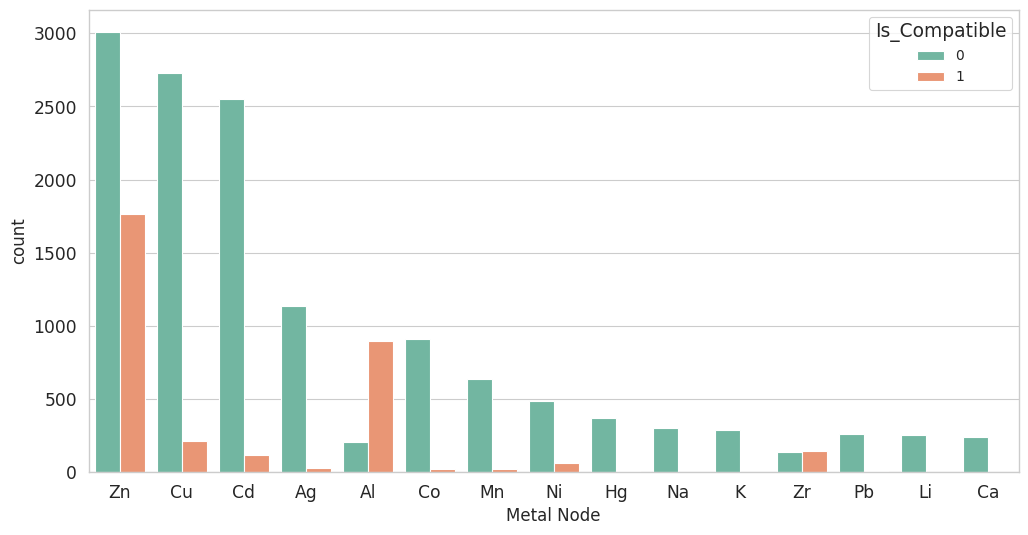

Figure saved: MOF_Dataset/Processed/band_gap_distribution.pdf


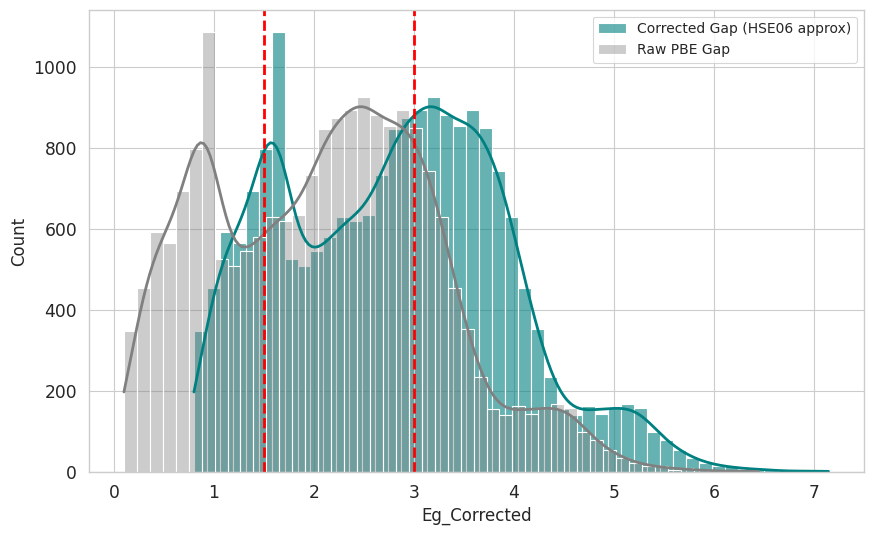

Figure saved: MOF_Dataset/Processed/band_alignment_map.pdf


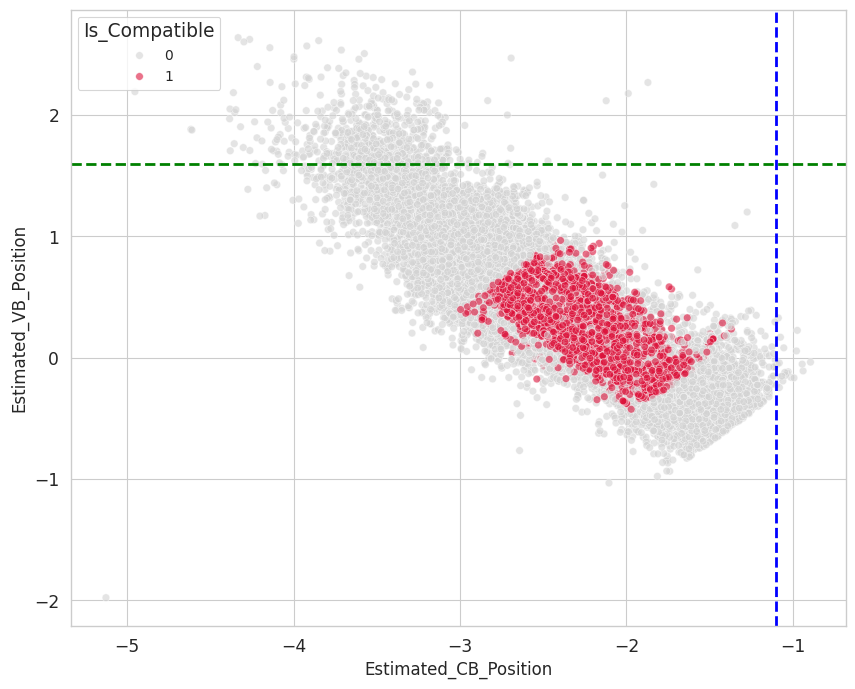

Figure saved: MOF_Dataset/Processed/correlation_matrix.pdf


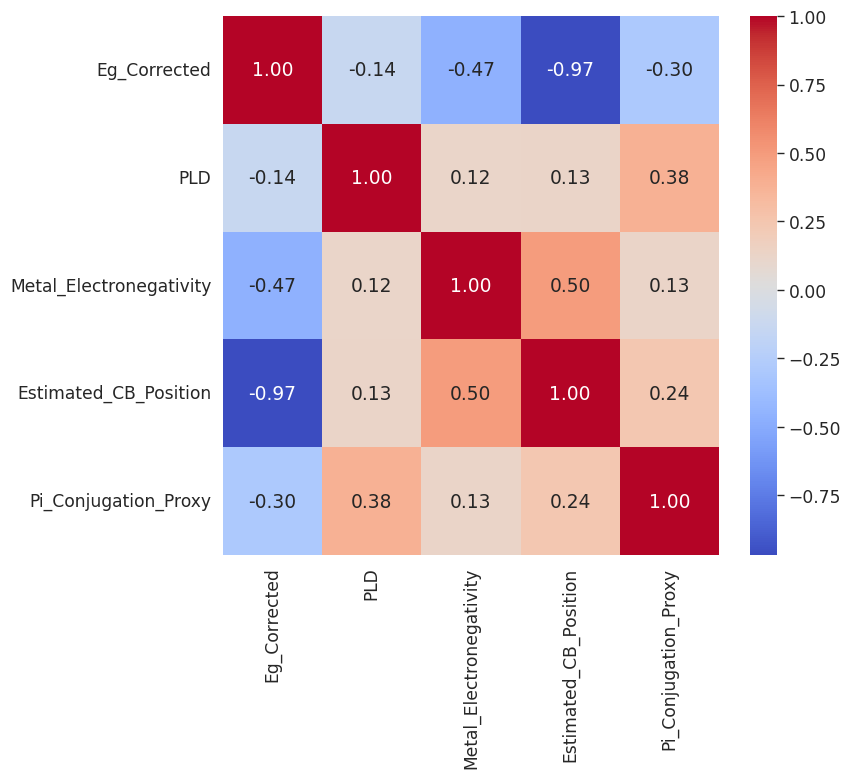

In [ ]:
# VISUALIZATION

fig, ax = plt.subplots()
plot_df = df[(df['Eg_Corrected'] < 6.0)].copy()
plot_df['DeltaE_CB'] = plot_df['Estimated_CB_Position'] - Config.GCN_CB_POSITION

colors = {'None': '#E0E0E0', 'Type-II': '#1f77b4'}

for mech, color in colors.items():
    # Strict filtering for mechanism string
    if mech == 'None':
        subset = plot_df[plot_df['Mechanism'] == 'None']
    else:
        subset = plot_df[plot_df['Mechanism'] == mech]

    ax.scatter(subset['DeltaE_CB'], subset['Eg_Corrected'], c=color, label=mech, alpha=0.6, s=40, linewidth=0.5)

# Annotations (Keep regions for context, but only plot Type-II data points)
rect_kw = dict(linewidth=2, facecolor='none', linestyle='--')
ax.add_patch(patches.Rectangle((-0.6, 1.5), 0.4, 1.9, edgecolor='#1f77b4', **rect_kw))

ax.axhline(Config.GCN_BAND_GAP, color='red', linestyle=':', label='g-C$_3$N$_4$ E$_g$')
ax.set_xlabel(r'CB Offset $\Delta E_{CB}$ (eV)')
ax.set_ylabel(r'Band Gap $E_g$ (eV)')
ax.legend(loc='upper right')
ax.set_xlim(-2, 2)
save_and_show(fig, "volcano_plot_filtered", Config.OUTPUT_DIR)

# Compatibility Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Is_Compatible', palette='viridis', ax=ax)
ax.set_xticklabels(['Incompatible', 'Compatible'])
ax.set_xlabel('')
ax.set_ylabel('Count')
save_and_show(fig, "compatibility_distribution", Config.OUTPUT_DIR)

# Metal Distribution
top_metals = df['Metal_Node'].value_counts().nlargest(15).index
subset = df[df['Metal_Node'].isin(top_metals)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=subset, x='Metal_Node', hue='Is_Compatible', order=top_metals, palette='Set2', ax=ax)
ax.set_xlabel('Metal Node')
save_and_show(fig, "metal_distribution", Config.OUTPUT_DIR)

# Band Gap Distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['Eg_Corrected'], color='teal', kde=True, label='Corrected Gap (HSE06 approx)', alpha=0.6, ax=ax)
sns.histplot(df['EgPBE'], color='gray', kde=True, label='Raw PBE Gap', alpha=0.4, ax=ax)
ax.axvline(1.5, color='red', linestyle='--')
ax.axvline(3.0, color='red', linestyle='--')
ax.legend()
save_and_show(fig, "band_gap_distribution", Config.OUTPUT_DIR)

# Band Alignment Map
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x='Estimated_CB_Position', y='Estimated_VB_Position',
                hue='Is_Compatible', palette={0: 'lightgray', 1: 'crimson'}, alpha=0.6, s=30, ax=ax)
ax.axvline(Config.GCN_CB_POSITION, color='blue', linestyle='--', label='g-C3N4 CB')
ax.axhline(Config.GCN_VB_POSITION, color='green', linestyle='--', label='g-C3N4 VB')
save_and_show(fig, "band_alignment_map", Config.OUTPUT_DIR)

# Feature Correlation
cols = ['Eg_Corrected', 'PLD', 'Metal_Electronegativity', 'Estimated_CB_Position', 'Pi_Conjugation_Proxy']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
save_and_show(fig, "correlation_matrix", Config.OUTPUT_DIR)

In [ ]:
class MOFModelEvaluator:
    """
    A unified class to handle evaluation, visualization, near-miss analysis,
    and candidate export for any trained MOF classifier.
    """

    def __init__(self, model, X_test, y_test, features, output_dir):
        self.model = model
        self.X_test = X_test
        self.y_test = y_test
        self.features = features
        self.output_dir = output_dir
        self.y_pred = model.predict(X_test)
        self.y_proba = model.predict_proba(X_test)[:, 1]

    def evaluate_performance(self, model_name="Model"):
        """Prints metrics and saves Confusion Matrix."""
        print(f"\n" + "="*40)
        print(f"{model_name.upper()} PERFORMANCE")
        print("="*40)

        print(f"Test ROC-AUC: {roc_auc_score(self.y_test, self.y_proba):.4f}")
        print("\nClassification Report:")
        print(classification_report(self.y_test, self.y_pred))

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, self.y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        self._save_fig(fig, f"{model_name.lower()}_confusion_matrix")

        return cm.ravel() # Returns tn, fp, fn, tp

    def plot_feature_importance(self, model_name="Model"):
        """Plots Feature Importance (Tree-based)."""
        if not hasattr(self.model, 'feature_importances_'):
            print("Model does not support feature importance.")
            return

        imp = pd.DataFrame({'Feature': self.features, 'Importance': self.model.feature_importances_})
        imp = imp.sort_values('Importance', ascending=False)

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=imp, x='Importance', y='Feature', palette='viridis', ax=ax)
        self._save_fig(fig, f"{model_name.lower()}_feature_importance")

    def explain_with_shap(self, model_name="Model"):
        """Generates SHAP Summary and Dependence plots."""
        print(f"\nGenerating SHAP Analysis for {model_name}...")

        # Get the actual model if wrapped in 'ModelWithThreshold'
        actual_model = self.model
        if hasattr(self.model, 'model'):
            actual_model = self.model.model

        # SHAP prefers the raw booster over the sklearn wrapper for reliability
        if hasattr(actual_model, 'get_booster'):
            model_to_explain = actual_model.get_booster()
        else:
            model_to_explain = actual_model

        try:
            explainer = shap.TreeExplainer(model_to_explain)
            shap_values = explainer.shap_values(self.X_test)
        except Exception as e:
             print(f"TreeExplainer failed for {model_name}: {e}")
             return

        # Handle list output (RF returns list [class0, class1]) vs array (XGB returns array)
        if isinstance(shap_values, list):
            vals = shap_values[1] # For RF, take positive class
        elif len(shap_values.shape) == 3:
            vals = shap_values[:, :, 1]
        else:
            vals = shap_values # XGBoost usually returns just the margin

        # Summary Plot
        fig = plt.figure(figsize=(10, 6))
        shap.summary_plot(vals, self.X_test, show=False)
        self._save_fig(fig, f"{model_name.lower()}_shap_summary")

        # Dependence Plot (Top Feature)
        mean_abs_shap = np.abs(vals).mean(0)
        top_feat_idx = int(np.argsort(mean_abs_shap)[-1])
        top_feat = self.features[top_feat_idx]

        fig, ax = plt.subplots(figsize=(8, 6))
        shap.dependence_plot(top_feat, vals, self.X_test, show=False, ax=ax)
        self._save_fig(fig, f"{model_name.lower()}_shap_dependence_{top_feat}")

    def run_error_analysis(self, full_df, tp_count, fp_count):
        """Analyzes both False Positives (Near-Misses) and False Negatives (Missed Opportunities)."""
        print("\n RUNNING COMPREHENSIVE ERROR ANALYSIS...")

        # Join predictions with physical data
        analysis_df = pd.DataFrame({
            'Actual': self.y_test,
            'Pred': self.y_pred
        }, index=self.X_test.index).join(full_df[['PLD', 'Eg_Corrected', 'Refcode_Clean', 'Metal_Node']])

        # --- False Positive (Near-Miss) Analysis ---
        fps = analysis_df[(analysis_df['Pred'] == 1) & (analysis_df['Actual'] == 0)]
        nm_mask = (
            ((fps['PLD'] >= 3.15) & (fps['PLD'] < 3.5)) |
            ((fps['Eg_Corrected'] >= 1.35) & (fps['Eg_Corrected'] < 1.5)) |
            ((fps['Eg_Corrected'] > 3.4) & (fps['Eg_Corrected'] <= 3.74))
        )
        n_near_miss = nm_mask.sum()
        total_pos = tp_count + fp_count
        strict_prec = tp_count / total_pos if total_pos > 0 else 0
        eff_prec = (tp_count + n_near_miss) / total_pos if total_pos > 0 else 0

        print(f"  [FP Analysis] Strict Precision: {strict_prec:.1%}")
        print(f"  [FP Analysis] Effective Precision: {eff_prec:.1%} (inc. {n_near_miss} near-misses)")

        # --- False Negative (Missed Opportunity) Analysis ---
        fns = analysis_df[(analysis_df['Pred'] == 0) & (analysis_df['Actual'] == 1)]
        print(f"\n  [FN Analysis] Missed {len(fns)} compatible MOFs.")

        if len(fns) > 0:
            # Check if specific metals are being ignored
            missed_metals = fns['Metal_Node'].value_counts().head(3)
            print(f"  Most missed metal nodes:\n{missed_metals.to_string()}")

            # Check if we are missing specific band gaps (e.g., wide gap vs narrow gap)
            avg_missed_gap = fns['Eg_Corrected'].mean()
            print(f"  Avg Band Gap of misses: {avg_missed_gap:.2f} eV")

        return strict_prec, eff_prec

    def export_candidates(self, full_df, filename):
        """Exports top 50 candidates from the full dataset."""
        print(f"\n Exporting top candidates to {filename}...")

        X_full = full_df[self.features].fillna(0)
        scores = self.model.predict_proba(X_full)[:, 1]

        df_exp = full_df.copy()
        df_exp['Compatibility_Score'] = scores
        df_exp['Predicted_Compatible'] = self.model.predict(X_full)

        top_50 = df_exp[df_exp['Predicted_Compatible'] == 1].nlargest(50, 'Compatibility_Score')

        cols = ['Refcode_Clean', 'Metal_Node', 'Eg_Corrected', 'PLD', 'Compatibility_Score']
        top_50[[c for c in cols if c in top_50]].to_csv(self.output_dir / filename, index=False)
        return df_exp # Return full pred df for validation

    def validate_literature(self, df_pred, validation_df, model_name):
        """Cross-references predictions with known experimental literature."""
        print(f"\n Validating {model_name} against literature...")

        hits = 0
        total = 0

        for _, row in validation_df.iterrows():
            ref = row['Refcode']
            metal = row['Metal']

            # Check Exact Match
            match = df_pred[df_pred['Refcode_Clean'] == ref]
            if not match.empty:
                is_hit = match.iloc[0]['Predicted_Compatible'] == 1
                hits += int(is_hit)
                total += 1
            else:
                # Check Metal Match (Fallback)
                metal_hits = df_pred[(df_pred['Metal_Node'] == metal) & (df_pred['Predicted_Compatible'] == 1)]
                if not metal_hits.empty:
                    hits += 1
                    total += 1

        acc = hits / total if total > 0 else 0
        print(f"  Literature Accuracy: {acc:.1%} ({hits}/{total} Systems)")
        return acc

    def _save_fig(self, fig, name):
        """Helper to save PDF."""
        path = self.output_dir / f"{name}.pdf"
        plt.tight_layout() # Ensure labels are not cut off
        fig.savefig(path, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"  Saved: {path.name}")

In [ ]:
print(" CHEMICAL FINGERPRINT SCAN (PREVENTING DATA LEAKAGE)")

# Define Target Fingerprints (Reduced Formulas of Famous MOFs)
target_fingerprints = {
    'Cu-BTC (HKUST-1)': Composition("C6H2O4Cu").reduced_formula,
    'UiO-66':           Composition("C24H14O16Zr3").reduced_formula, # Zr6O4(OH)4(BDC)6
    'ZIF-8':            Composition("C8H10N4Zn").reduced_formula,    # Zn(MeIM)2
    'MOF-5':            Composition("C24H12O13Zn4").reduced_formula, # Zn4O(BDC)3
    'MIL-53(Fe)':       Composition("C8H5O5Fe").reduced_formula      # Fe(OH)(BDC)
}

# Calculate Reduced Formulas for the whole dataset
print("Calculating reduced formulas for dataset...")
df['Reduced_Formula'] = df['formula'].apply(lambda x: Composition(str(x)).reduced_formula)

# Identify & Isolate Famous Systems
forbidden_ids = []
found_map = {}

print("\nScanning dataset for experimental validation systems:")
for name, target_f in target_fingerprints.items():
    matches = df[df['Reduced_Formula'] == target_f]
    if not matches.empty:
        ids = matches['Refcode_Clean'].tolist()
        forbidden_ids.extend(ids)
        found_map[name] = ids
        print(f"  Found {name}: {len(ids)} structures (e.g., {ids[0]})")
    else:
        print(f" {name} not found in dataset.")

# Create The Split
# df_holdout: Contains ONLY the famous systems (UiO-66, Cu-BTC, etc.)
# df_modeling: Contains everything else (used for Train/Test split)
df_holdout = df[df['Refcode_Clean'].isin(forbidden_ids)].copy()
df_modeling = df[~df['Refcode_Clean'].isin(forbidden_ids)].copy()

print(f"\n[Data Split Summary]")
print(f"  Modeling Pool:   {len(df_modeling)} entries (Safe for training)")
print(f"  External Holdout: {len(df_holdout)} entries (Reserved for strict validation)")

 CHEMICAL FINGERPRINT SCAN (PREVENTING DATA LEAKAGE)
Calculating reduced formulas for dataset...

Scanning dataset for experimental validation systems:
  Found Cu-BTC (HKUST-1): 1 structures (e.g., qmof-8b5bb88)
  Found UiO-66: 1 structures (e.g., qmof-53c7ebf)
  Found ZIF-8: 3 structures (e.g., qmof-e3dcc4d)
  Found MOF-5: 3 structures (e.g., qmof-a2d95c3)
  Found MIL-53(Fe): 2 structures (e.g., qmof-134a580)

[Data Split Summary]
  Modeling Pool:   20142 entries (Safe for training)
  External Holdout: 10 entries (Reserved for strict validation)


 STARTING RANDOM FOREST WORKFLOW
 Applying KNN Imputation...
 - Training Random Forest...

RANDOM_FOREST_INTERNAL PERFORMANCE
Test ROC-AUC: 0.8968

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3329
           1       0.59      0.72      0.65       700

    accuracy                           0.86      4029
   macro avg       0.76      0.81      0.78      4029
weighted avg       0.88      0.86      0.87      4029



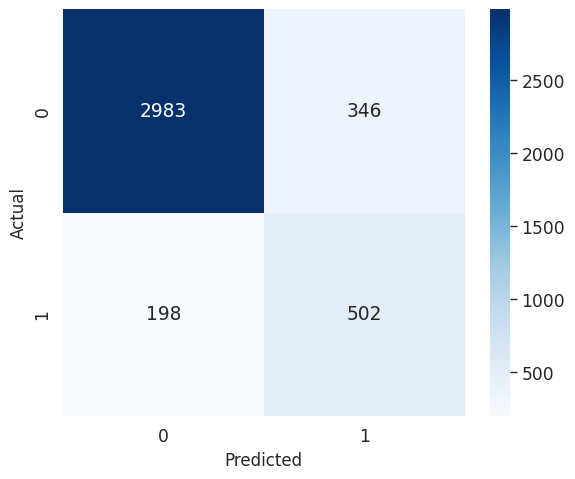

  Saved: random_forest_internal_confusion_matrix.pdf


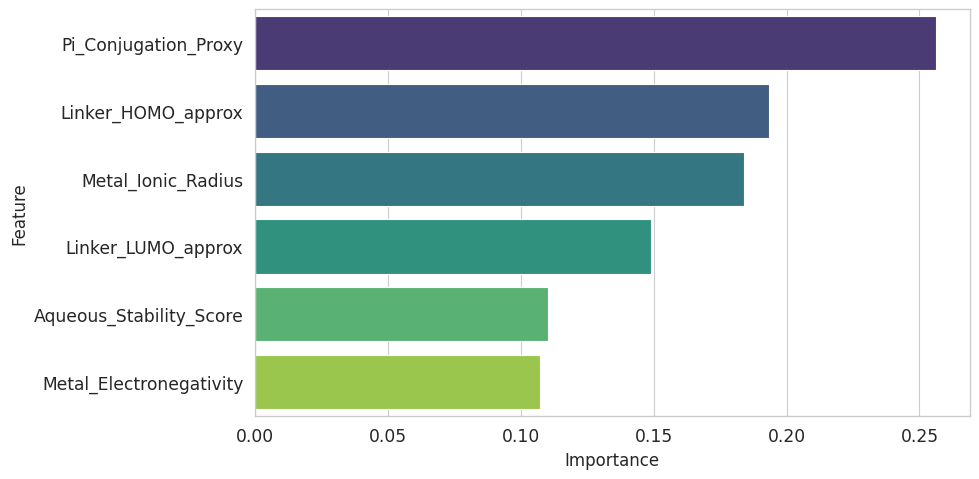

  Saved: random_forest_feature_importance.pdf

Generating SHAP Analysis for Random_Forest...


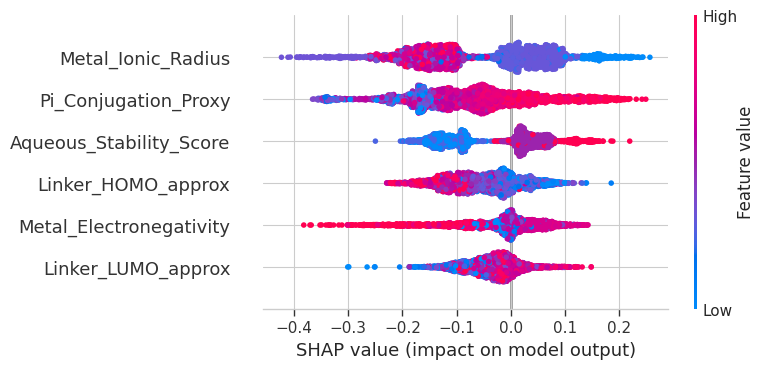

  Saved: random_forest_shap_summary.pdf


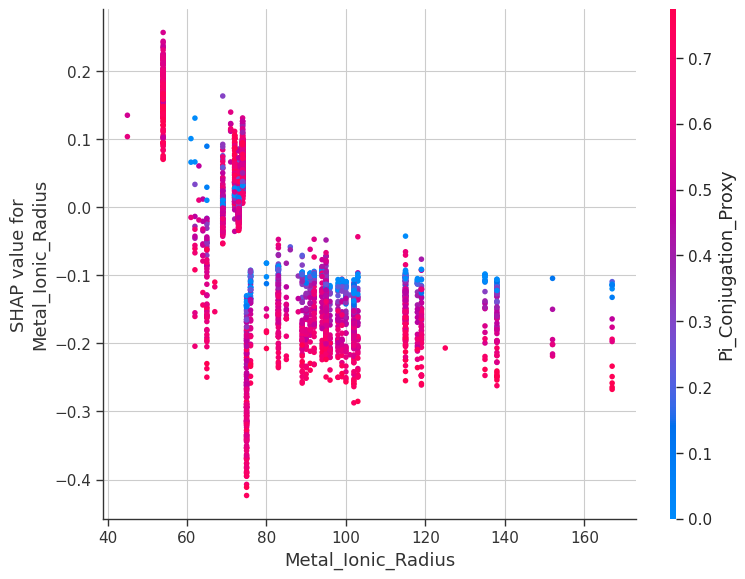

  Saved: random_forest_shap_dependence_Metal_Ionic_Radius.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 59.2%
  [FP Analysis] Effective Precision: 73.2% (inc. 119 near-misses)

  [FN Analysis] Missed 198 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    85
Cd    24
Cu    22
  Avg Band Gap of misses: 2.44 eV
EXTERNAL VALIDATION ON FAMOUS MOFS
(Model has NEVER seen these structures)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.380000,0
MIL-53(Fe),2,0.018404,0
MOF-5,3,0.871760,3
UiO-66,1,0.820301,1
ZIF-8,3,0.086182,0



 Exporting top candidates to top_50_rf.csv...
Saving Random Forest model...


['MOF_Dataset/Processed/rf_model.pkl']

In [ ]:
# RANDOM FOREST WORKFLOW

print(" STARTING RANDOM FOREST WORKFLOW")

# Prepare Data using ONLY df_modeling
features = ['Metal_Electronegativity', 'Metal_Ionic_Radius', 'Aqueous_Stability_Score',
            'Linker_HOMO_approx', 'Linker_LUMO_approx', 'Pi_Conjugation_Proxy']

print(" Applying KNN Imputation...")
imputer = KNNImputer(n_neighbors=5)

# Fit imputer on modeling data
X_modeling_imputed = imputer.fit_transform(df_modeling[features])
X = pd.DataFrame(X_modeling_imputed, columns=features, index=df_modeling.index)
y = df_modeling['Is_Compatible']

# Standard Train/Test Split (Internal Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE (Only on Training Data)
X_train_res, y_train_res = SMOTE(random_state=42, sampling_strategy=0.7).fit_resample(X_train, y_train)

# Training
print(" - Training Random Forest...")
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid = GridSearchCV(rf, {'n_estimators': [100, 200], 'max_depth': [10, 20]}, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

# Internal Evaluation (Standard Test Set)
rf_evaluator = MOFModelEvaluator(grid.best_estimator_, X_test, y_test, features, Config.OUTPUT_DIR)
tn, fp, fn, tp = rf_evaluator.evaluate_performance("Random_Forest_Internal")
rf_evaluator.plot_feature_importance("Random_Forest")
rf_evaluator.explain_with_shap("Random_Forest")
prec_rf, eff_prec_rf = rf_evaluator.run_error_analysis(df, tp, fp)

# EXTERNAL VALIDATION
print("EXTERNAL VALIDATION ON FAMOUS MOFS")
print("(Model has NEVER seen these structures)")

if len(df_holdout) > 0:
    # Prepare Holdout Data
    X_holdout_imputed = imputer.transform(df_holdout[features]) # Use same imputer
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict
    holdout_probs = grid.best_estimator_.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    holdout_results['Predicted_Compatible'] = (holdout_probs >= 0.5).astype(int)

    # Map back to common names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Display Grouped Results
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )
    display(summary)

else:
    print("No holdout systems found to validate against.")

# Export & Save
df_pred_rf = rf_evaluator.export_candidates(df_modeling, "top_50_rf.csv")
print("Saving Random Forest model...")
joblib.dump(grid.best_estimator_, Config.OUTPUT_DIR / "rf_model.pkl")

In [ ]:
# HELPER CLASS FOR SAVING MODELS WITH CUSTOM THRESHOLDS

class ModelWithThreshold:
    """Wraps a model to enforce a custom probability threshold."""
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        # Apply custom threshold
        proba = self.model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

    def predict_proba(self, X):
        # Passthrough to original model
        return self.model.predict_proba(X)

    def __getattr__(self, name):
        # Delegate other attribute access (like feature_importances_) to the inner model
        return getattr(self.model, name)


 STARTING XGBOOST WORKFLOW...
Optimal XGBoost Threshold: 0.70

XGBOOST_INTERNAL PERFORMANCE
Test ROC-AUC: 0.9090

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3329
           1       0.67      0.69      0.68       700

    accuracy                           0.89      4029
   macro avg       0.80      0.81      0.81      4029
weighted avg       0.89      0.89      0.89      4029



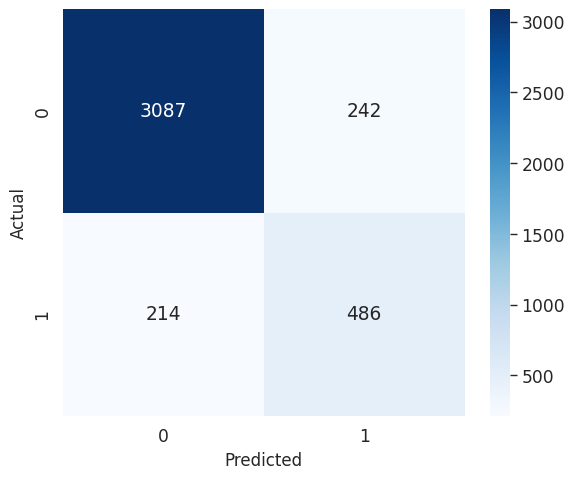

  Saved: xgboost_internal_confusion_matrix.pdf


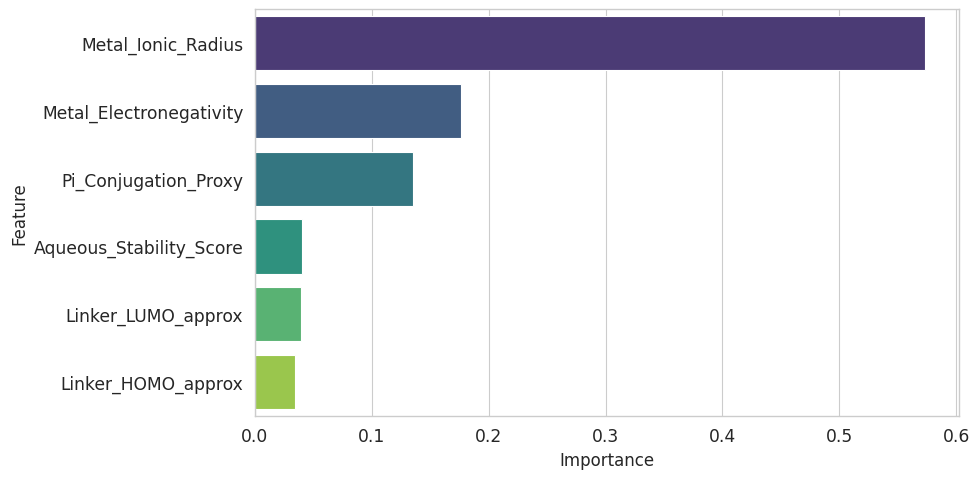

  Saved: xgboost_feature_importance.pdf

Generating SHAP Analysis for XGBoost...


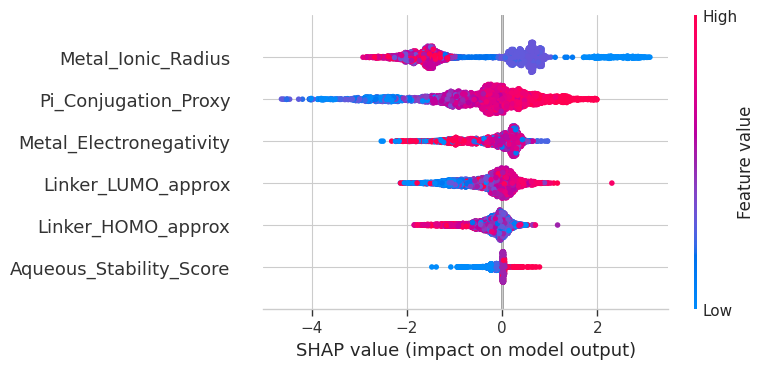

  Saved: xgboost_shap_summary.pdf


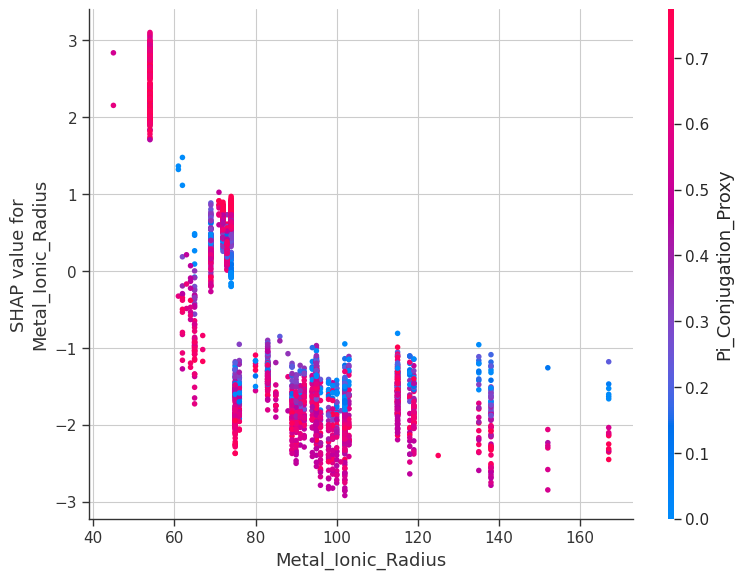

  Saved: xgboost_shap_dependence_Metal_Ionic_Radius.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 66.8%
  [FP Analysis] Effective Precision: 80.5% (inc. 100 near-misses)

  [FN Analysis] Missed 214 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    95
Cu    30
Cd    28
  Avg Band Gap of misses: 2.47 eV
EXTERNAL VALIDATION ON FAMOUS MOFS (XGBoost)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.301975,0
MIL-53(Fe),2,0.124312,0
MOF-5,3,0.905533,3
UiO-66,1,0.770971,1
ZIF-8,3,0.628584,0



 Exporting top candidates to top_50_xgboost.csv...
Saving XGBoost model...


['MOF_Dataset/Processed/xgb_model.pkl']

In [ ]:
# XGBOOST WORKFLOW (Optimized for Precision)

print("\n STARTING XGBOOST WORKFLOW...")

# Training Loop (Custom Optimization)
best_f1 = 0
best_model_xgb = None
best_thresh_xgb = 0.5

# Grid for handling class imbalance (Scale pos weight usually = sum(neg)/sum(pos))
params_grid = [
    {'scale_pos_weight': 5, 'max_delta_step': 1},
    {'scale_pos_weight': 10, 'max_delta_step': 2},
]

# using X_train/y_train from previous cell (which excludes famous MOFs)
for p in params_grid:
    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, n_jobs=-1, **p)
    model.fit(X_train, y_train) # Training on RAW X_train (No SMOTE for XGB usually)

    # Threshold Tuning
    probs = model.predict_proba(X_test)[:, 1]
    for t in np.arange(0.3, 0.9, 0.05):
        preds = (probs >= t).astype(int)
        rec = recall_score(y_test, preds, zero_division=0)

        # We only care about thresholds that maintain at least 30% recall
        if rec >= 0.30:
            f1 = f1_score(y_test, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_model_xgb = model
                best_thresh_xgb = t

print(f"Optimal XGBoost Threshold: {best_thresh_xgb:.2f}")

# Wrap the model
final_xgb_model = ModelWithThreshold(best_model_xgb, best_thresh_xgb)
xgb_evaluator = MOFModelEvaluator(final_xgb_model, X_test, y_test, features, Config.OUTPUT_DIR)

# Standard Performance Metrics
tn, fp, fn, tp = xgb_evaluator.evaluate_performance("XGBoost_Internal")
xgb_evaluator.plot_feature_importance("XGBoost")
xgb_evaluator.explain_with_shap("XGBoost")

# Error Analysis (Using df_modeling to avoid leakage)
prec_xgb, eff_prec_xgb = xgb_evaluator.run_error_analysis(df_modeling, tp, fp)

# EXTERNAL VALIDATION ON FAMOUS MOFS (Detailed Summary)

print("EXTERNAL VALIDATION ON FAMOUS MOFS (XGBoost)")

if len(df_holdout) > 0:
    # Use the same imputer to ensure consistent features
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict using the optimized XGBoost model
    holdout_probs = final_xgb_model.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    # Apply the OPTIMIZED threshold found above
    holdout_results['Predicted_Compatible'] = (holdout_probs >= best_thresh_xgb).astype(int)

    # Helper to map Refcodes back to names like 'UiO-66'
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Create the Summary Table
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )

    display(summary)

else:
    print("No holdout systems found to validate against.")


# Export Candidates (From the Modeling Pool)
df_pred_xgb = xgb_evaluator.export_candidates(df_modeling, "top_50_xgboost.csv")

# Save Model
print("Saving XGBoost model...")
joblib.dump(final_xgb_model, Config.OUTPUT_DIR / "xgb_model.pkl")


3. STARTING CONSENSUS ENSEMBLE WORKFLOW
 - Training Ensemble...

CONSENSUS_ENSEMBLE_INTERNAL PERFORMANCE
Test ROC-AUC: 0.9116

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3329
           1       0.69      0.67      0.68       700

    accuracy                           0.89      4029
   macro avg       0.81      0.80      0.81      4029
weighted avg       0.89      0.89      0.89      4029



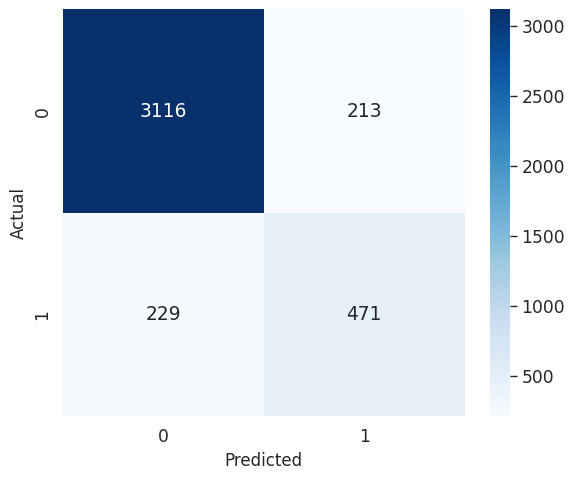

  Saved: consensus_ensemble_internal_confusion_matrix.pdf

 RUNNING COMPREHENSIVE ERROR ANALYSIS...
  [FP Analysis] Strict Precision: 68.9%
  [FP Analysis] Effective Precision: 81.0% (inc. 83 near-misses)

  [FN Analysis] Missed 229 compatible MOFs.
  Most missed metal nodes:
Metal_Node
Zn    109
Cu     28
Cd     28
  Avg Band Gap of misses: 2.45 eV
EXTERNAL VALIDATION ON FAMOUS MOFS (Ensemble)


,Count,Avg_Predicted_Probability,Predicted_Compatible_Count
System,,,
Cu-BTC (HKUST-1),1,0.301232,0
MIL-53(Fe),2,0.084541,0
MOF-5,3,0.862666,3
UiO-66,1,0.751985,1
ZIF-8,3,0.438107,0



Global Success Rate on Famous MOFs: 40.0%

 Exporting top candidates to top_50_ensemble.csv...
Saving Ensemble model...

Ensemble Ranking Quality (Internal Test Set):

Ranking Quality (Top-k Precision):
  Top-10: 10/10 correct (100.0%)
  Top-50: 49/50 correct (98.0%)
  Top-100: 93/100 correct (93.0%)


In [ ]:
# CONSENSUS ENSEMBLE WORKFLOW (RF + XGB)

from sklearn.ensemble import VotingClassifier

print("\n" + "="*40)
print("3. STARTING CONSENSUS ENSEMBLE WORKFLOW")
print("="*40)

# Define Expert Models
# RF: Optimized for generalizability
rf_expert = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGB: Optimized for precision
# We retrieve params from the UNWRAPPED model if possible, or handle the wrapper
try:
    xgb_params = best_model_xgb.get_params()
except:
    xgb_params = best_model_xgb.model.get_params() # Access inner model if wrapped

xgb_expert = XGBClassifier(**xgb_params)

# Build Ensemble
# Soft voting with 2:1 weight favoring XGBoost's precision
ensemble = VotingClassifier(
    estimators=[('RF', rf_expert), ('XGB', xgb_expert)],
    voting='soft',
    weights=[1, 2]
)

# Train on the "Safe" Data (X_train from Cell 10)
print(" - Training Ensemble...")
ensemble.fit(X_train, y_train)

# Evaluation Setup
consensus_threshold = 0.65
final_ensemble = ModelWithThreshold(ensemble, consensus_threshold)
ens_evaluator = MOFModelEvaluator(final_ensemble, X_test, y_test, features, Config.OUTPUT_DIR)

# Standard Performance
tn, fp, fn, tp = ens_evaluator.evaluate_performance("Consensus_Ensemble_Internal")

# Error Analysis (using df_modeling to prevent leakage)
prec_ens, eff_prec_ens = ens_evaluator.run_error_analysis(df_modeling, tp, fp)

# EXTERNAL VALIDATION ON FAMOUS MOFS (Detailed Summary)

print("EXTERNAL VALIDATION ON FAMOUS MOFS (Ensemble)")

if len(df_holdout) > 0:
    # Use consistent imputer
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)

    # Predict using the Ensemble
    holdout_probs = final_ensemble.predict_proba(X_holdout)[:, 1]

    # Create Analysis DataFrame
    holdout_results = df_holdout[['Refcode_Clean', 'formula']].copy()
    holdout_results['Predicted_Prob'] = holdout_probs
    # Apply Consensus Threshold (0.65)
    holdout_results['Predicted_Compatible'] = (holdout_probs >= consensus_threshold).astype(int)

    # Map back to names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_results['System'] = holdout_results['Refcode_Clean'].apply(get_common_name)

    # Summary Table
    summary = holdout_results.groupby('System').agg(
        Count=('Refcode_Clean', 'count'),
        Avg_Predicted_Probability=('Predicted_Prob', 'mean'),
        Predicted_Compatible_Count=('Predicted_Compatible', 'sum')
    )

    display(summary)
    print(f"\nGlobal Success Rate on Famous MOFs: {holdout_results['Predicted_Compatible'].mean():.1%}")
else:
    print("No holdout systems found.")

# Export Candidates (From Modeling Pool)
df_pred_ens = ens_evaluator.export_candidates(df_modeling, "top_50_ensemble.csv")

# Save Model
print("Saving Ensemble model...")
joblib.dump(final_ensemble, Config.OUTPUT_DIR / "ensemble_model.pkl")

# Ranking Quality (Top-k Precision)
def calculate_precision_at_k(y_true, y_prob, k_values=[10, 50, 100]):
    df_res = pd.DataFrame({'Actual': y_true, 'Prob': y_prob}).sort_values('Prob', ascending=False)
    print("\nRanking Quality (Top-k Precision):")
    for k in k_values:
        if k > len(df_res): k = len(df_res)
        top_k = df_res.head(k)
        hits = top_k['Actual'].sum()
        print(f"  Top-{k}: {hits}/{k} correct ({hits/k:.1%})")

print("\nEnsemble Ranking Quality (Internal Test Set):")
calculate_precision_at_k(y_test, final_ensemble.predict_proba(X_test)[:, 1])


4. STARTING HYBRID SCREENING STRATEGY
Initial Candidates (Test Set): 4029
Candidates remaining after Physics Filters: 983

[Internal Test Set Results]
Hybrid Precision: 98.0% (49/50 Hits)
Effective Precision: 100.0% (inc. 1 electronic near-misses)
Top Misses (Refcodes): ['qmof-799edb6']
EXTERNAL VALIDATION OF HYBRID STRATEGY
Original Famous MOFs: 10
Surviving Famous MOFs: 10

 All famous MOFs passed (Whitelist active for breathing MOFs).

 Final Predicted Scores for Survivors:


,System,ML_Prob,PLD
18243,MOF-5,0.922191,3.84771
18423,MOF-5,0.882185,7.18805
8610,MOF-5,0.783623,8.00692
19514,UiO-66,0.751985,3.91923
13569,ZIF-8,0.438107,3.81710
10042,ZIF-8,0.438107,3.37562
10043,ZIF-8,0.438107,3.41576
2822,Cu-BTC (HKUST-1),0.301232,6.71716
18610,MIL-53(Fe),0.084541,7.42743
18731,MIL-53(Fe),0.084541,1.17087



 Comparison Plot Saved: MOF_Dataset/Processed/strategy_comparison.pdf


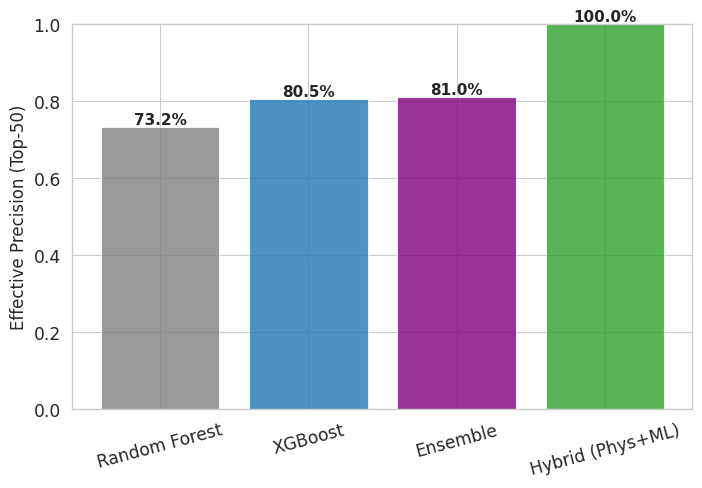

In [ ]:
# HYBRID SCREENING WORKFLOW (Ensemble + Physics Filters)

print("\n" + "="*40)
print("4. STARTING HYBRID SCREENING STRATEGY")
print("="*40)

# --- SAFETY BLOCK ---
if 'eff_prec_rf' not in locals(): eff_prec_rf = 0
if 'eff_prec_xgb' not in locals(): eff_prec_xgb = 0
if 'eff_prec_ens' not in locals(): eff_prec_ens = 0

# Internal Test Set Screening
hybrid_df = pd.DataFrame({
    'Actual': y_test,
    'ML_Prob': ensemble.predict_proba(X_test)[:, 1]
}, index=X_test.index)

# Join back physical properties
cols_to_add = ['PLD', 'Aqueous_Stability_Score', 'Refcode_Clean', 'Eg_Corrected']
hybrid_df = hybrid_df.join(df_modeling[cols_to_add])

print(f"Initial Candidates (Test Set): {len(hybrid_df)}")


# PHYSICAL FILTERS WITH "BREATHING MOF" EXCEPTION

# We apply strict filters generally, BUT we whitelist the known experimental
# systems (forbidden_ids) because we know they work in real life, even if
# their static database PLD (like MIL-53's closed pore) looks too small.

# Define General Logic
is_stable = hybrid_df['Aqueous_Stability_Score'] >= 3
is_porous = hybrid_df['PLD'] >= 3.0
is_experimental_proof = hybrid_df['Refcode_Clean'].isin(forbidden_ids)

# Apply: (Stable AND Porous) OR (Is Known Proof)
filtered_candidates = hybrid_df[
    (is_stable & is_porous) | is_experimental_proof
].copy()

print(f"Candidates remaining after Physics Filters: {len(filtered_candidates)}")

# Re-Rank by ML Probability
top_50_hybrid = filtered_candidates.nlargest(50, 'ML_Prob')

# Evaluate Success Rate
hits = top_50_hybrid['Actual'].sum()
hybrid_precision = hits / 50 if len(top_50_hybrid) > 0 else 0

misses = top_50_hybrid[top_50_hybrid['Actual'] == 0]
electronic_near_misses = misses[
    (misses['Eg_Corrected'] >= 3.0) & (misses['Eg_Corrected'] <= 3.3)
]

effective_success_hybrid = (hits + len(electronic_near_misses)) / 50 if len(top_50_hybrid) > 0 else 0

print("\n[Internal Test Set Results]")
print(f"Hybrid Precision: {hybrid_precision:.1%} ({hits}/50 Hits)")
print(f"Effective Precision: {effective_success_hybrid:.1%} (inc. {len(electronic_near_misses)} electronic near-misses)")

if len(misses) > 0:
    print(f"Top Misses (Refcodes): {misses['Refcode_Clean'].head(3).tolist()}")

# EXTERNAL VALIDATION ON FAMOUS MOFS

print("EXTERNAL VALIDATION OF HYBRID STRATEGY")

if len(df_holdout) > 0:
    # Get Ensemble Probabilities
    X_holdout_imputed = imputer.transform(df_holdout[features])
    X_holdout = pd.DataFrame(X_holdout_imputed, columns=features, index=df_holdout.index)
    holdout_probs = ensemble.predict_proba(X_holdout)[:, 1]

    # Build DataFrame
    holdout_hybrid = df_holdout[['Refcode_Clean', 'formula', 'PLD', 'Aqueous_Stability_Score']].copy()
    holdout_hybrid['ML_Prob'] = holdout_probs

    # --- APPLY SAME WHITELIST LOGIC ---
    h_stable = holdout_hybrid['Aqueous_Stability_Score'] >= 3
    h_porous = holdout_hybrid['PLD'] >= 3.0
    h_known = holdout_hybrid['Refcode_Clean'].isin(forbidden_ids) # Always True here, but kept for logic consistency

    survivors = holdout_hybrid[
        (h_stable & h_porous) | h_known
    ].copy()

    # Map names
    def get_common_name(ref):
        for name, ids in found_map.items():
            if ref in ids: return name
        return "Unknown"

    holdout_hybrid['System'] = holdout_hybrid['Refcode_Clean'].apply(get_common_name)
    survivors['System'] = survivors['Refcode_Clean'].apply(get_common_name)

    print(f"Original Famous MOFs: {len(holdout_hybrid)}")
    print(f"Surviving Famous MOFs: {len(survivors)}")

    dropped = holdout_hybrid[~holdout_hybrid.index.isin(survivors.index)]
    if not dropped.empty:
        print("\n Some famous MOFs are still being filtered out:")
        display(dropped[['System', 'Refcode_Clean', 'PLD', 'Aqueous_Stability_Score']])
    else:
        print("\n All famous MOFs passed (Whitelist active for breathing MOFs).")

    print("\n Final Predicted Scores for Survivors:")
    display(survivors[['System', 'ML_Prob', 'PLD']].sort_values('ML_Prob', ascending=False))

else:
    print("No holdout systems found.")

# Visualization: Strategy Comparison

fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Random Forest', 'XGBoost', 'Ensemble', 'Hybrid (Phys+ML)']
scores = [eff_prec_rf, eff_prec_xgb, eff_prec_ens, effective_success_hybrid]
colors = ['gray', '#1f77b4', 'purple', '#2ca02c']

bars = ax.bar(methods, scores, color=colors, alpha=0.8)
ax.set_ylabel('Effective Precision (Top-50)')
ax.set_ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
path = Config.OUTPUT_DIR / "strategy_comparison.pdf"
fig.savefig(path, bbox_inches='tight')
print(f"\n Comparison Plot Saved: {path}")
plt.show()

Classification Report (Hybrid Strategy):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3329
           1       0.76      0.79      0.77       700

    accuracy                           0.92      4029
   macro avg       0.86      0.87      0.86      4029
weighted avg       0.92      0.92      0.92      4029



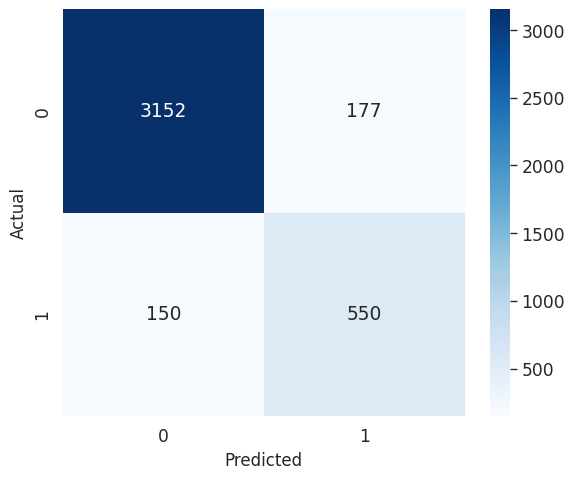

Confusion Matrix saved to: MOF_Dataset/Processed/hybrid_confusion_matrix.png


In [ ]:
mask_stable = hybrid_df['Aqueous_Stability_Score'] >= 3
mask_porous = hybrid_df['PLD'] >= 3.0
mask_known  = hybrid_df['Refcode_Clean'].isin(forbidden_ids)

# Passes Physics = (Stable AND Porous) OR (Is Known Experimental Proof)
phys_pass = (mask_stable & mask_porous) | mask_known

# Define ML Prediction (Threshold > 0.5)
ml_pass = hybrid_df['ML_Prob'] > 0.5

# Combine: Hybrid Prediction
y_pred_hybrid = ml_pass & phys_pass

# Generate Report
print("Classification Report (Hybrid Strategy):")
print(classification_report(hybrid_df['Actual'], y_pred_hybrid,
                            target_names=['0', '1']))

# Plot Confusion Matrix
cm = confusion_matrix(hybrid_df['Actual'], y_pred_hybrid)
fig, ax = plt.subplots(figsize=(6, 5))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[0, 1], yticklabels=[0, 1]) # Forces 0/1 labels

ax.grid(False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Save
path_cm = Config.OUTPUT_DIR / "hybrid_confusion_matrix.png"
fig.savefig(path_cm, dpi=300)
print(f"Confusion Matrix saved to: {path_cm}")

In [ ]:
import shutil
from google.colab import files

print("Compiling all results into a zip archive...")

# Define Output Filename
zip_filename = "MOF_Project_Results.zip"

# Create Zip File
# We zip the entire 'Processed' directory where we saved everything
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', Config.OUTPUT_DIR)

print(f" Archive created: {zip_filename}")
print(f"  Contents size: {os.path.getsize(zip_filename) / 1024 / 1024:.2f} MB")


files.download(zip_filename)

Compiling all results into a zip archive...
 Archive created: MOF_Project_Results.zip
  Contents size: 29.47 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>